In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [12]:
import os
print(os.listdir('/kaggle/input'))
from scipy import stats

['competitions']


In [13]:
import os
print(os.listdir('/kaggle/input/competitions'))

['titanic']


In [14]:
import os
print(os.listdir('/kaggle/input/competitions/titanic'))

['train.csv', 'test.csv', 'gender_submission.csv']


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Correct path!
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

# Basic exploration
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

Survived
0    549
1    342
Name: count, dtype: int64
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


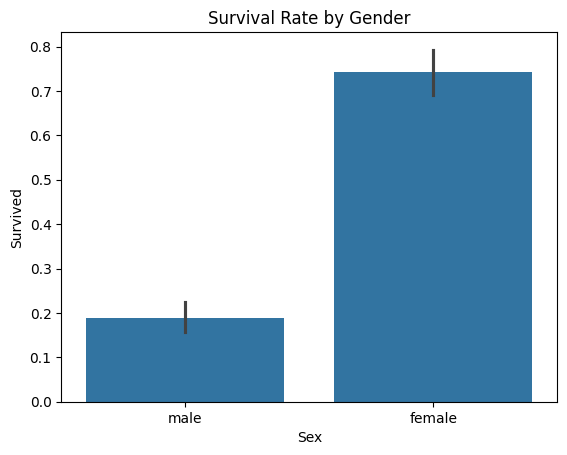

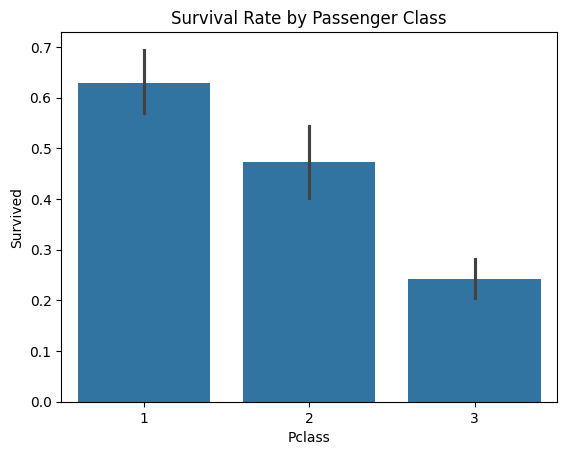

In [16]:
# How many survived vs died?
print(df["Survived"].value_counts())

# Survival rate by gender
print(df.groupby("Sex")["Survived"].mean())

# Survival rate by passenger class
print(df.groupby("Pclass")["Survived"].mean())

# Visualize survival by gender
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Gender")
plt.show()

# Visualize survival by class
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.show()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64


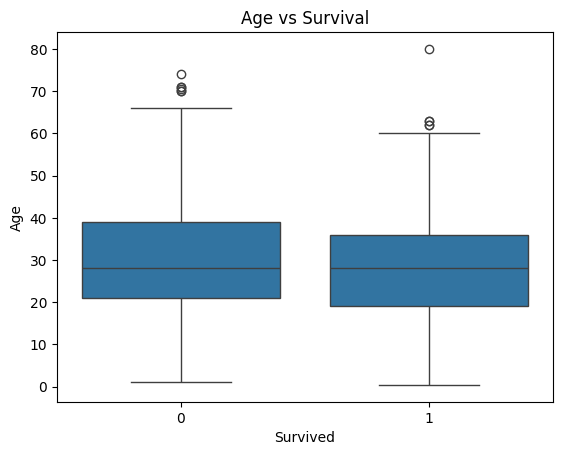

P-value: 0.03912465401348249


In [17]:
# Average age of survivors vs non survivors
print(df.groupby("Survived")["Age"].mean())

# Visualize age distribution
sns.boxplot(data=df, x="Survived", y="Age")
plt.title("Age vs Survival")
plt.show()

# Hypothesis test - is age difference significant?
survived = df[df["Survived"]==1]["Age"].dropna()
not_survived = df[df["Survived"]==0]["Age"].dropna()
t_stat, p_value = stats.ttest_ind(survived, not_survived)
print("P-value:", p_value)

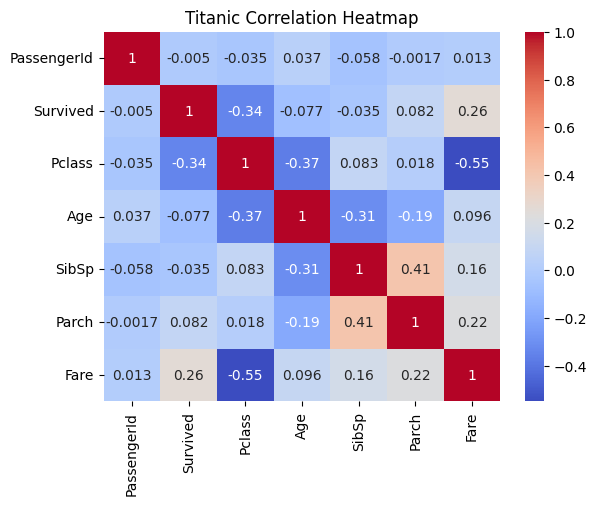

In [19]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Correlation heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Titanic Correlation Heatmap")
plt.show()

In [20]:
# Fix Age
df["Age"].fillna(df["Age"].median(), inplace=True)

# Fix Embarked
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop Cabin
df.drop("Cabin", axis=1, inplace=True)

# Verify - should show all zeros now!
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_55/2865185574.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_55/2865185574.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us